# Name: Muhammad Danial Maqbool
# Student ID: 25280029

Github Link: https://github.com/danial-maqbool/25280029_AI-600_PA-3

All analytical questions are added in the pdf.


# Task 1 - Part A



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

In [2]:
trans = transforms.Compose([transforms.ToTensor()])

t_data = datasets.MNIST('./data', train=True, download=True, transform=trans)
v_data = datasets.MNIST('./data', train=False, transform=trans)

t_ldr = DataLoader(t_data, batch_size=64, shuffle=True)
v_ldr = DataLoader(v_data, batch_size=64, shuffle=False)

In [3]:
class NetA(nn.Module):
    def __init__(self):
        super(NetA, self).__init__()
        # Conv Layer 1: 1 input channel, 8 output channels, 3x3 kernel with MaxPool 2x2
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Conv Layer 2: 8 input channels, 16 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        
        # After two 2x2 pools, a 28x28 image becomes 7x7. 
        # Flattened size = 16 * 7 * 7 = 784
        self.fc1 = nn.Linear(784, 48)
        self.fc2 = nn.Linear(48, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 784) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net_a = NetA()

total_p = sum(p.numel() for p in net_a.parameters() if p.requires_grad)
print(f"Total Params: {total_p}")

Total Params: 39418


In [4]:
opt = optim.Adam(net_a.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

epochs = 5
t_loss_h = []
v_loss_h = []
t_acc_h = []
v_acc_h = []

for ep in range(epochs):
    # Training Phase
    net_a.train()
    r_loss = 0.0
    r_corr = 0
    tot = 0
    
    for imgs, lbls in t_ldr:
        opt.zero_grad()
        outs = net_a(imgs)
        loss = loss_fn(outs, lbls)
        loss.backward()
        opt.step()
        
        r_loss += loss.item()
        _, preds = torch.max(outs, 1)
        r_corr += (preds == lbls).sum().item()
        tot += lbls.size(0)
        
    t_loss_h.append(r_loss / len(t_ldr))
    t_acc_h.append(r_corr / tot)
    
    # Evaluation Phase
    net_a.eval()
    v_loss = 0.0
    v_corr = 0
    v_tot = 0
    
    with torch.no_grad():
        for v_imgs, v_lbls in v_ldr:
            v_outs = net_a(v_imgs)
            v_l = loss_fn(v_outs, v_lbls)
            
            v_loss += v_l.item()
            _, v_pred = torch.max(v_outs, 1)
            v_corr += (v_pred == v_lbls).sum().item()
            v_tot += v_lbls.size(0)
            
    v_loss_h.append(v_loss / len(v_ldr))
    v_acc_h.append(v_corr / v_tot)
    
    print(f"Ep {ep+1} | T-Loss: {t_loss_h[-1]:.3f} | V-Loss: {v_loss_h[-1]:.3f} | T-Acc: {t_acc_h[-1]:.3f} | V-Acc: {v_acc_h[-1]:.3f} |")

Ep 1 | T-Loss: 0.386 | V-Loss: 0.106 | T-Acc: 0.881 | V-Acc: 0.966 |
Ep 2 | T-Loss: 0.094 | V-Loss: 0.083 | T-Acc: 0.971 | V-Acc: 0.972 |
Ep 3 | T-Loss: 0.067 | V-Loss: 0.058 | T-Acc: 0.979 | V-Acc: 0.982 |
Ep 4 | T-Loss: 0.053 | V-Loss: 0.041 | T-Acc: 0.984 | V-Acc: 0.987 |
Ep 5 | T-Loss: 0.045 | V-Loss: 0.042 | T-Acc: 0.985 | V-Acc: 0.986 |


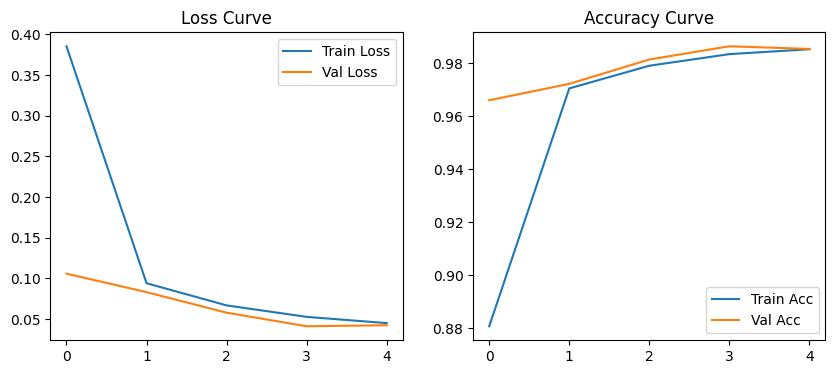

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(t_loss_h, label='Train Loss')
ax1.plot(v_loss_h, label='Val Loss')
ax1.legend()
ax1.set_title("Loss Curve")

ax2.plot(t_acc_h, label='Train Acc')
ax2.plot(v_acc_h, label='Val Acc')
ax2.legend()
ax2.set_title("Accuracy Curve")
plt.show()

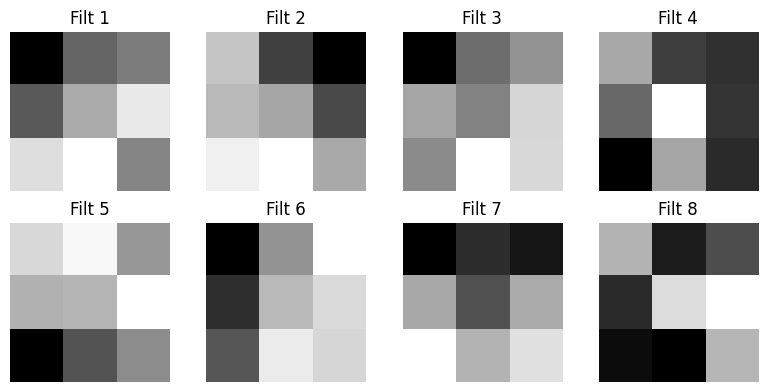

In [6]:
wts = net_a.conv1.weight.data.numpy()

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    filt_img = wts[i][0] 
    ax.imshow(filt_img, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Filt {i+1}')
    
plt.tight_layout()
plt.show()


# Task 1 - Part B

In [7]:
def prep_ds(raw):
    if isinstance(raw, dict):
        im = raw['images']
        lb = raw['labels']
    else:
        if raw[0].dim() == 4:
            im, lb = raw[0], raw[1]
        else:
            im, lb = raw[1], raw[0]
            
    return TensorDataset(im.float(), lb.long())

t_raw = torch.load('train_biased.pt')
b_raw = torch.load('test_biased.pt')
u_raw = torch.load('test_unbiased.pt')

ds_tr = prep_ds(t_raw)
ds_tb = prep_ds(b_raw)
ds_tu = prep_ds(u_raw)

ldr_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
ldr_tb = DataLoader(ds_tb, batch_size=64, shuffle=False)
ldr_tu = DataLoader(ds_tu, batch_size=64, shuffle=False)

In [8]:
class NetB(nn.Module):
    def __init__(self):
        super(NetB, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        
        self.fc1 = nn.Linear(784, 48)
        self.fc2 = nn.Linear(48, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 784) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net_b = NetB()

In [9]:
opt_b = optim.Adam(net_b.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
eps = 5

for ep in range(eps):
    # Training Phase
    net_b.train()
    r_loss = 0.0
    r_corr = 0
    tot = 0
    
    for imgs, lbls in ldr_tr:
        opt_b.zero_grad()
        outs = net_b(imgs)
        loss = loss_fn(outs, lbls)
        loss.backward()
        opt_b.step()
        
        r_loss += loss.item()
        _, preds = torch.max(outs, 1)
        r_corr += (preds == lbls).sum().item()
        tot += lbls.size(0)
        
    t_loss = r_loss / len(ldr_tr)
    t_acc = r_corr / tot
    
    # Evaluation Phase (Using Biased Test as Validation for the print out)
    net_b.eval()
    v_loss = 0.0
    v_corr = 0
    v_tot = 0
    
    with torch.no_grad():
        for v_imgs, v_lbls in ldr_tb:
            v_outs = net_b(v_imgs)
            v_l = loss_fn(v_outs, v_lbls)
            
            v_loss += v_l.item()
            _, v_pred = torch.max(v_outs, 1)
            v_corr += (v_pred == v_lbls).sum().item()
            v_tot += v_lbls.size(0)
            
    val_loss = v_loss / len(ldr_tb)
    val_acc = v_corr / v_tot
    
    print(f"Ep {ep+1} | T-Loss: {t_loss:.3f} | V-Loss: {val_loss:.3f} | T-Acc: {t_acc:.3f} | V-Acc: {val_acc:.3f} |")

print("-" * 60)

Ep 1 | T-Loss: 0.263 | V-Loss: 0.085 | T-Acc: 0.929 | V-Acc: 0.975 |
Ep 2 | T-Loss: 0.076 | V-Loss: 0.055 | T-Acc: 0.978 | V-Acc: 0.983 |
Ep 3 | T-Loss: 0.049 | V-Loss: 0.036 | T-Acc: 0.985 | V-Acc: 0.990 |
Ep 4 | T-Loss: 0.037 | V-Loss: 0.033 | T-Acc: 0.989 | V-Acc: 0.990 |
Ep 5 | T-Loss: 0.030 | V-Loss: 0.034 | T-Acc: 0.991 | V-Acc: 0.990 |
------------------------------------------------------------


In [10]:
def chk_acc(ldr, nme):
    net_b.eval()
    crr = 0
    tot = 0
    with torch.no_grad():
        for ims, lbs in ldr:
            out = net_b(ims)
            _, prd = torch.max(out, 1)
            crr += (prd == lbs).sum().item()
            tot += lbs.size(0)
    print(f"Final {nme} Acc: {crr/tot:.3f}")

chk_acc(ldr_tb, "Biased Test")
chk_acc(ldr_tu, "Unbiased Test")

Final Biased Test Acc: 0.990
Final Unbiased Test Acc: 0.875



# Task 2 - Part A

In [11]:
tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download and load STL-10
stl_tr = datasets.STL10('./data', split='train', download=True, transform=tfms)
stl_te = datasets.STL10('./data', split='test', download=True, transform=tfms)

ldr_stl_tr = DataLoader(stl_tr, batch_size=64, shuffle=True)
ldr_stl_te = DataLoader(stl_te, batch_size=64, shuffle=False)

100%|██████████| 2.64G/2.64G [1:22:41<00:00, 532kB/s]   


In [12]:
res_net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for p in res_net.parameters():
    p.requires_grad = False

num_ftrs = res_net.fc.in_features
res_net.fc = nn.Linear(num_ftrs, 10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\dania/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:31<00:00, 1.51MB/s]


In [13]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
res_net = res_net.to(dev)

opt_res = optim.Adam(res_net.fc.parameters(), lr=0.001)
loss_fn_res = nn.CrossEntropyLoss()
eps_res = 5

for ep in range(eps_res):
    # Training Phase
    res_net.train()
    r_loss = 0.0
    r_corr = 0
    tot = 0
    
    for imgs, lbls in ldr_stl_tr:
        imgs, lbls = imgs.to(dev), lbls.to(dev)
        
        opt_res.zero_grad()
        outs = res_net(imgs)
        loss = loss_fn_res(outs, lbls)
        loss.backward()
        opt_res.step()
        
        r_loss += loss.item()
        _, preds = torch.max(outs, 1)
        r_corr += (preds == lbls).sum().item()
        tot += lbls.size(0)
        
    t_loss = r_loss / len(ldr_stl_tr)
    t_acc = r_corr / tot
    
    # Evaluation Phase
    res_net.eval()
    v_loss = 0.0
    v_corr = 0
    v_tot = 0
    
    with torch.no_grad():
        for v_imgs, v_lbls in ldr_stl_te:
            v_imgs, v_lbls = v_imgs.to(dev), v_lbls.to(dev)
            
            v_outs = res_net(v_imgs)
            v_l = loss_fn_res(v_outs, v_lbls)
            
            v_loss += v_l.item()
            _, v_pred = torch.max(v_outs, 1)
            v_corr += (v_pred == v_lbls).sum().item()
            v_tot += v_lbls.size(0)
            
    val_loss = v_loss / len(ldr_stl_te)
    val_acc = v_corr / v_tot
    
    print(f"Ep {ep+1} | T-Loss: {t_loss:.3f} | V-Loss: {val_loss:.3f} | T-Acc: {t_acc:.3f} | V-Acc: {val_acc:.3f} |")

Ep 1 | T-Loss: 0.906 | V-Loss: 0.359 | T-Acc: 0.782 | V-Acc: 0.923 |
Ep 2 | T-Loss: 0.308 | V-Loss: 0.247 | T-Acc: 0.935 | V-Acc: 0.936 |
Ep 3 | T-Loss: 0.233 | V-Loss: 0.216 | T-Acc: 0.945 | V-Acc: 0.940 |
Ep 4 | T-Loss: 0.198 | V-Loss: 0.194 | T-Acc: 0.947 | V-Acc: 0.943 |
Ep 5 | T-Loss: 0.174 | V-Loss: 0.182 | T-Acc: 0.954 | V-Acc: 0.944 |



# Task 2 - Part B

In [19]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

for p in res_net.parameters():
    p.requires_grad = True

tgt_lyr = [res_net.layer4[-1]]
cam = GradCAM(model=res_net, target_layers=tgt_lyr)

res_net.eval()
c_imgs, c_lbls, c_prds = [], [], []
i_imgs, i_lbls, i_prds = [], [], []

for v_imgs, v_lbls in ldr_stl_te:
    v_imgs, v_lbls = v_imgs.to(dev), v_lbls.to(dev)
    
    v_outs = res_net(v_imgs)
    _, v_pred = torch.max(v_outs, 1)
    
    for i in range(len(v_lbls)):
        if len(c_imgs) < 2 and v_pred[i] == v_lbls[i]:
            c_imgs.append(v_imgs[i].cpu())
            c_lbls.append(v_lbls[i].cpu().item())
            c_prds.append(v_pred[i].cpu().item())
            
        elif len(i_imgs) < 2 and v_pred[i] != v_lbls[i]:
            i_imgs.append(v_imgs[i].cpu())
            i_lbls.append(v_lbls[i].cpu().item())
            i_prds.append(v_pred[i].cpu().item())
            
        if len(c_imgs) == 2 and len(i_imgs) == 2:
            break
    if len(c_imgs) == 2 and len(i_imgs) == 2:
        break

all_imgs = c_imgs + i_imgs
all_lbls = c_lbls + i_lbls
all_prds = c_prds + i_prds

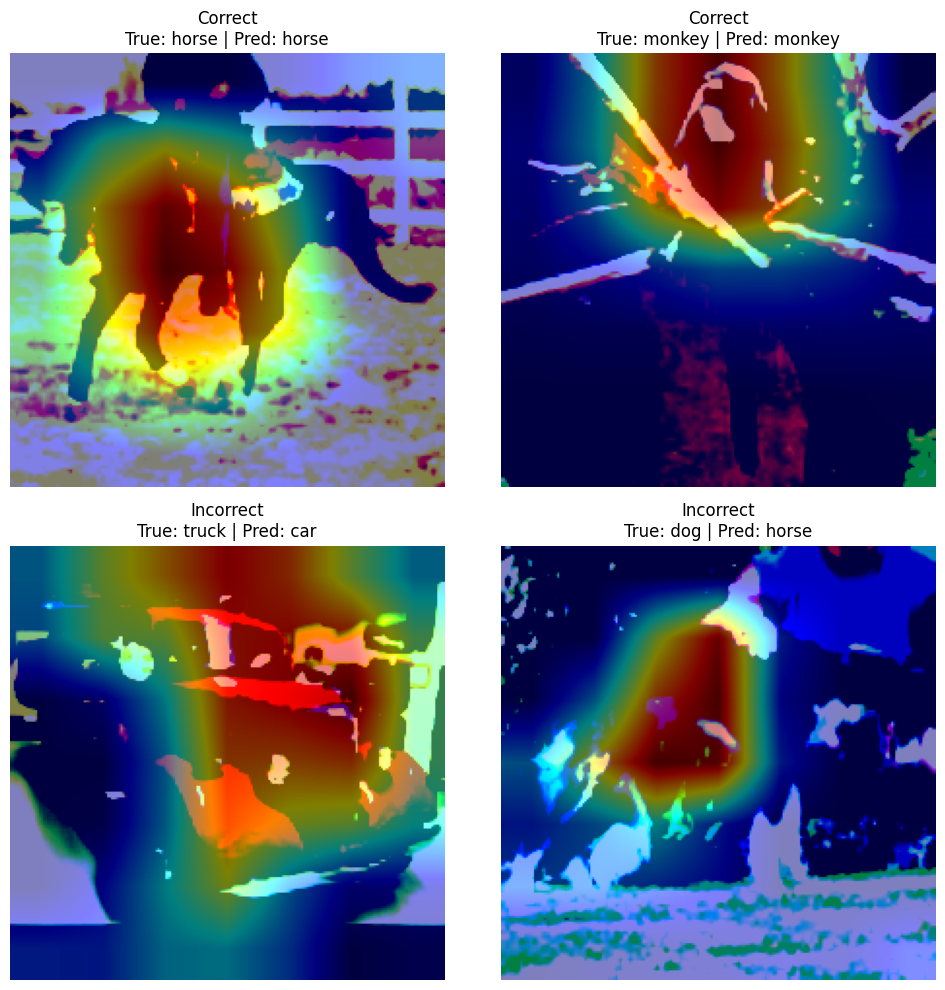

In [20]:
inv_mu = np.array([-0.485/0.229, -0.456/0.224, -0.406/0.225])
inv_std = np.array([1/0.229, 1/0.224, 1/0.225])

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
classes = stl_tr.classes

for idx, ax in enumerate(axes.flat):
    img_t = all_imgs[idx].unsqueeze(0).to(dev)
    tgt = [ClassifierOutputTarget(all_lbls[idx])]
    
    grsk_cam = cam(input_tensor=img_t, targets=tgt)[0, :]
    
    vis_img = all_imgs[idx].permute(1, 2, 0).numpy()
    vis_img = inv_std * vis_img + inv_mu
    vis_img = np.clip(vis_img, 0, 1)
    
    cam_img = show_cam_on_image(vis_img, grsk_cam, use_rgb=True)
    
    ax.imshow(cam_img)
    ax.axis('off')
    
    stat = "Correct" if idx < 2 else "Incorrect"
    ax.set_title(f"{stat}\nTrue: {classes[all_lbls[idx]]} | Pred: {classes[all_prds[idx]]}")

plt.tight_layout()
plt.show()